# 03 Feature Importance

## Business objective
This notebook interprets the Phase 1 LightGBM baseline model for next-day terminal dwell forecasting.

The goal is to understand which operational features are most influential in the model's predictions and whether those relationships make business sense in a freight rail context.

This notebook does **not** tune the model yet. It focuses on interpreting the existing baseline before moving to later steps such as hyperparameter tuning and error analysis.

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import shap

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

## Load and prepare the Phase 1 dataset

In this section, we load the synthetic terminal dwell dataset, sort it consistently, and define the feature columns and target variable used in the baseline model.

To keep interpretation valid, this notebook will reuse the same target and feature structure as the baseline modeling notebook.

In [5]:
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
df.columns = df.columns.str.strip()
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

print("Data path:", data_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Data path: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv
Shape: (8760, 13)

Columns:
['date', 'terminal_id', 'terminal_name', 'region', 'inbound_train_count', 'inbound_car_count', 'cars_on_hand', 'yard_occupancy_pct', 'crew_starts_available', 'locomotive_availability_pct', 'is_weekend', 'month', 'target_dwell_hours']


,date,terminal_id,terminal_name,region,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,target_dwell_hours
0,2022-01-01,T01,Barstow,West,13,304,532,59.1,13,92.3,1,1,19.7
1,2022-01-02,T01,Barstow,West,11,223,461,51.2,11,95.3,1,1,19.5
2,2022-01-03,T01,Barstow,West,10,219,448,49.8,18,85.7,0,1,20.0
3,2022-01-04,T01,Barstow,West,7,138,350,38.9,14,88.5,0,1,20.4
4,2022-01-05,T01,Barstow,West,9,175,361,40.1,17,90.5,0,1,20.7


In [6]:
target_col = "target_dwell_hours"

feature_cols = [
    "terminal_id",
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Number of features:", len(feature_cols))
print("Target column:", target_col)
print("Features:")
for col in feature_cols:
    print("-", col)

Number of features: 9
Target column: target_dwell_hours
Features:
- terminal_id
- inbound_train_count
- inbound_car_count
- cars_on_hand
- yard_occupancy_pct
- crew_starts_available
- locomotive_availability_pct
- is_weekend
- month


In [7]:
split_date = "2024-07-01"

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train date range:", df.loc[train_mask, "date"].min(), "to", df.loc[train_mask, "date"].max())
print("Test date range:", df.loc[test_mask, "date"].min(), "to", df.loc[test_mask, "date"].max())

Train shape: (7296, 9)
Test shape: (1464, 9)
Train date range: 2022-01-01 00:00:00 to 2024-06-30 00:00:00
Test date range: 2024-07-01 00:00:00 to 2024-12-30 00:00:00


In [8]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["terminal_id"] = X_train["terminal_id"].astype("category")
X_test["terminal_id"] = X_test["terminal_id"].astype("category")

print(X_train.dtypes)

terminal_id                    category
inbound_train_count               int64
inbound_car_count                 int64
cars_on_hand                      int64
yard_occupancy_pct              float64
crew_starts_available             int64
locomotive_availability_pct     float64
is_weekend                        int64
month                             int64
dtype: object


## Train the baseline model for interpretation

The model below uses the exact hyperparameters from the Notebook 02 baseline (`n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=20, subsample=0.8, colsample_bytree=0.8, random_state=42`). SHAP values are computed on this model to ensure feature-importance findings are consistent with the published baseline metrics (RMSE 3.841, MAE 2.942).

In [10]:
model = LGBMRegressor(
    objective="regression",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    categorical_feature=["terminal_id"]
)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print(f"LightGBM RMSE: {rmse:.3f}")
print(f"LightGBM MAE: {mae:.3f}")

LightGBM RMSE: 3.841
LightGBM MAE: 2.942


In [11]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df

,feature,importance
0,locomotive_availability_pct,2756
1,inbound_car_count,2643
2,crew_starts_available,1450
3,cars_on_hand,1280
4,month,1257
5,inbound_train_count,1110
6,yard_occupancy_pct,979
7,terminal_id,326
8,is_weekend,199


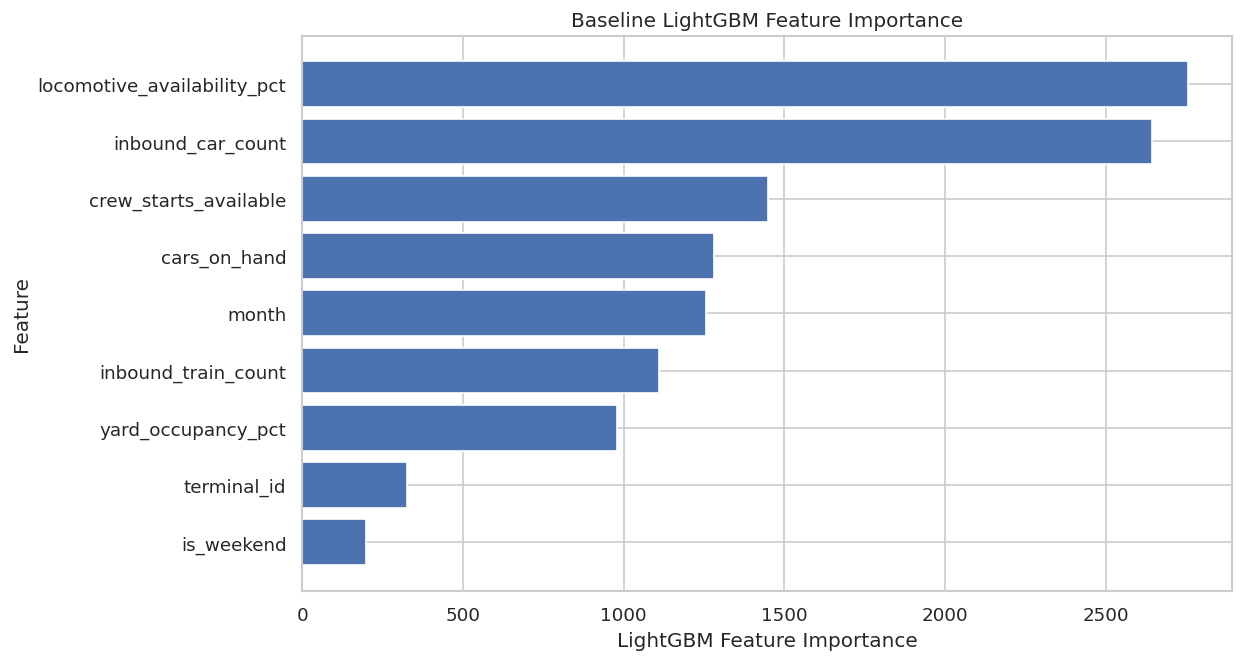

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("LightGBM Feature Importance")
plt.ylabel("Feature")
plt.title("Baseline LightGBM Feature Importance")
plt.show()

## Initial interpretation

The baseline LightGBM model relies most heavily on the operational features with the highest importance scores. In a freight rail setting, features such as yard occupancy, cars on hand, inbound volume, and crew or locomotive availability should plausibly influence next-day terminal dwell because they reflect congestion, workload, and available operating capacity.

These importance values show which variables the model used most often to reduce prediction error, but they do not yet show whether a feature tends to push predicted dwell upward or downward. That directional interpretation will come next with SHAP analysis.

## SHAP analysis

Built-in LightGBM feature importance shows which variables were most useful to the model overall, but it does not show the direction of each feature’s effect on predicted dwell. In this section, SHAP (SHapley Additive exPlanations) is used to interpret how individual features influence the model’s predictions.

The SHAP summary views help answer questions such as whether higher inbound volume tends to increase predicted dwell, whether stronger crew or locomotive availability tends to reduce predicted dwell, and how much variation in prediction impact each feature creates across observations.

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (1464, 9)


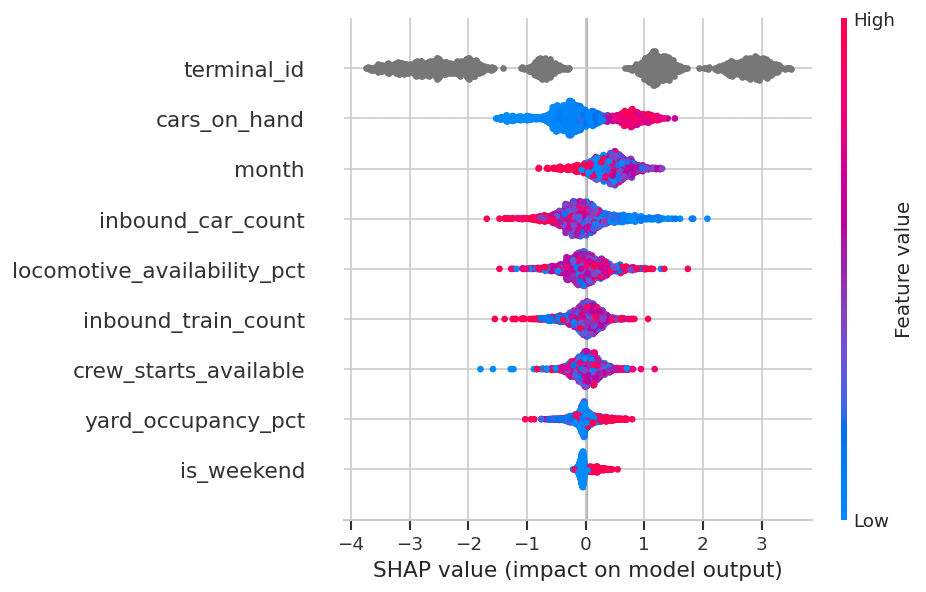

In [14]:
shap.summary_plot(shap_values, X_test, plot_type="dot")

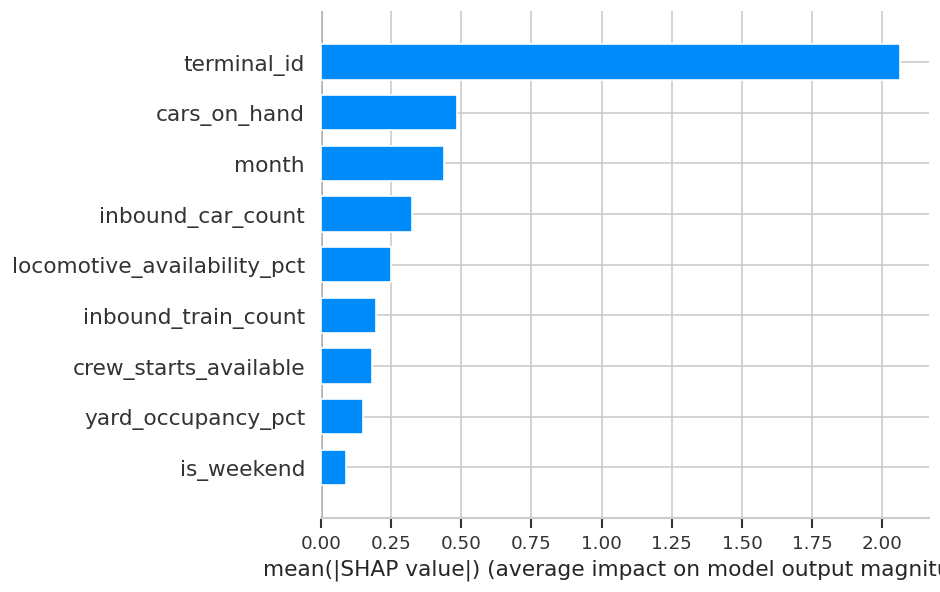

In [15]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## SHAP interpretation

Three direct findings from the SHAP summary plot:

1. **`locomotive_availability_pct` and `inbound_car_count` are the strongest operational drivers.** These two features produce the widest range of SHAP values across test observations, meaning they shift predicted dwell the most from day to day. Higher inbound car counts push predicted dwell up; lower locomotive availability does the same — both reflecting increased workload or reduced processing capacity at the terminal.

2. **`terminal_id` shows a meaningful but more compact effect than the built-in importance ranking suggested.** In the SHAP dot plot, terminal identity shifts predictions by a consistent offset within a relatively narrow band — confirming the model has learned stable yard-level baselines. This is predictable and operationally sound, but it also means the model is partially compensating for yard differences rather than explaining them through observable features.

3. **`crew_starts_available` and `month` show directional effects consistent with operational expectations.** Lower crew availability tends to push predicted dwell upward. Month effects are visible and seasonal: summer and harvest-period months show higher SHAP contributions, consistent with the volume patterns in the synthetic generator. `is_weekend` has the smallest average SHAP magnitude, suggesting the weekend flag adds limited marginal signal once the other features are present.

## Optional test: remove terminal identity

To evaluate how much of the model’s predictive power depends on terminal-specific effects, this section retrains the same baseline LightGBM model without `terminal_id`.

This comparison helps separate the value of operational drivers from the value of stable yard-level patterns. If performance remains close to the full model, that suggests the operational features explain most of the signal. If performance worsens materially, terminal-specific effects are playing a larger role in prediction.

In [16]:
feature_cols_no_terminal = [
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

X_no_terminal = df[feature_cols_no_terminal].copy()

X_train_no_terminal = X_no_terminal.loc[train_mask].copy()
X_test_no_terminal = X_no_terminal.loc[test_mask].copy()

print("Number of features without terminal_id:", len(feature_cols_no_terminal))
print("Features without terminal_id:")
for col in feature_cols_no_terminal:
    print("-", col)

Number of features without terminal_id: 8
Features without terminal_id:
- inbound_train_count
- inbound_car_count
- cars_on_hand
- yard_occupancy_pct
- crew_starts_available
- locomotive_availability_pct
- is_weekend
- month


In [17]:
model_no_terminal = LGBMRegressor(
    objective="regression",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model_no_terminal.fit(X_train_no_terminal, y_train)

y_pred_no_terminal = model_no_terminal.predict(X_test_no_terminal)

mse_no_terminal = mean_squared_error(y_test, y_pred_no_terminal)
rmse_no_terminal = mse_no_terminal ** 0.5
mae_no_terminal = mean_absolute_error(y_test, y_pred_no_terminal)

print(f"LightGBM without terminal_id RMSE: {rmse_no_terminal:.3f}")
print(f"LightGBM without terminal_id MAE: {mae_no_terminal:.3f}")

LightGBM without terminal_id RMSE: 3.852
LightGBM without terminal_id MAE: 2.984


In [18]:
comparison_df = pd.DataFrame({
    "model": ["LightGBM full model", "LightGBM without terminal_id"],
    "RMSE": [rmse, rmse_no_terminal],
    "MAE": [mae, mae_no_terminal]
})

comparison_df["RMSE_change_vs_full"] = comparison_df["RMSE"] - rmse
comparison_df["MAE_change_vs_full"] = comparison_df["MAE"] - mae

comparison_df

,model,RMSE,MAE,RMSE_change_vs_full,MAE_change_vs_full
0,LightGBM full model,3.840708,2.942340,0.000000,0.000000
1,LightGBM without terminal_id,3.852303,2.983634,0.011595,0.041294


## Optional test interpretation: removing terminal identity

Removing `terminal_id` caused only a small decline in model performance. RMSE increased from **3.841** to **3.852**, and MAE increased from **2.942** to **2.984**. This suggests that terminal-specific effects provide some incremental predictive value, but most of the model’s performance is still coming from the operational variables.

This is an encouraging result for the business framing of the project. It indicates that next-day terminal dwell can be explained largely through workload, congestion, resource availability, and seasonal conditions rather than primarily through yard identity alone. In later phases, terminal-specific effects may still be useful, but this comparison supports the idea that the model is learning meaningful operational drivers that could be used for decision support.

## Conclusion

The Phase 1 feature-importance analysis showed that the baseline LightGBM model relies on a mix of operational and seasonal signals, including inbound volume, cars on hand, crew availability, locomotive availability, and month effects. Built-in feature importance identified the most influential variables overall, while SHAP analysis provided a more detailed view of how these features affect predictions across observations.

An additional comparison without `terminal_id` showed only modest performance degradation, indicating that most of the model’s predictive strength comes from operational features rather than from yard identity alone. This supports the project’s central business framing: next-day terminal dwell can be forecasted using upstream operational drivers, which makes the model more relevant for decision support than a purely location-dependent baseline. The next step is to tune the LightGBM model to determine whether predictive accuracy can be improved further without changing the business framing.